In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

In [5]:
data_picked = data[['Kwh', 'temp', 'dew', 'humidity', 'precip', 'windgust', 'windspeed', 'winddir', 'cloudcover', 'solarradiation']]

In [6]:
x = data_picked.iloc[:, 1:].values
y = data_picked.iloc[:, 0].values

x, y

(array([[  6.  ,   2.  ,  75.51, ..., 240.  ,   0.  ,   0.  ],
        [  6.  ,   2.  ,  75.51, ..., 298.1 ,   0.  ,   0.  ],
        [  4.9 ,   2.  ,  81.61, ..., 301.  ,  40.9 ,   0.  ],
        ...,
        [ 21.  ,  10.  ,  49.39, ...,   0.  ,  63.7 ,   9.  ],
        [ 20.  ,  11.  ,  56.15, ...,   0.  ,  65.5 ,   0.  ],
        [ 18.  ,  11.  ,  63.61, ...,   0.  ,  68.3 ,   0.  ]]),
 array([0., 0., 0., ..., 0., 0., 0.]))

In [7]:
x_train, x_test = x[: int(0.95 * len(x))] , x[int(0.95 * len(x)):]
y_train, y_test = y[: int(0.95 * len(y))], y[int(0.95 * len(y)):] 

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((20883, 9), (1100, 9), (20883,), (1100,))

In [8]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_x.fit_transform(x_train)
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

x_test = scaler_x.transform(x_test)
y_test = scaler_y.transform(y_test.reshape(-1, 1)).ravel()


In [9]:
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

svr_model.fit(x_train, y_train)


SVR()

In [10]:
y_pred = svr_model.predict(x_test)
y_pred

array([-0.6281611 , -0.55988006, -0.72119882, ..., -0.53877641,
       -0.56465591, -0.51502478])

In [11]:
y_pred = svr_model.predict(x_test)

y_pred = y_pred.reshape(-1, 1)
y_pred = scaler_y.inverse_transform(y_pred)

y_test = y_test.reshape(-1, 1)
y_test = scaler_y.inverse_transform(y_test)

y_pred = y_pred.ravel()
y_test = y_test.ravel()


In [12]:
y_pred = np.where(y_pred< 0 , 0, y_pred)

In [13]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

Mean Squared Error: 0.0097225536707497
R² Score: 0.8519817987700995


In [14]:
date_range = pd.date_range(start='2024/1/3 19:00:00', end='2024/7/4 23:00:00', freq='H')
len(date_range)

4397

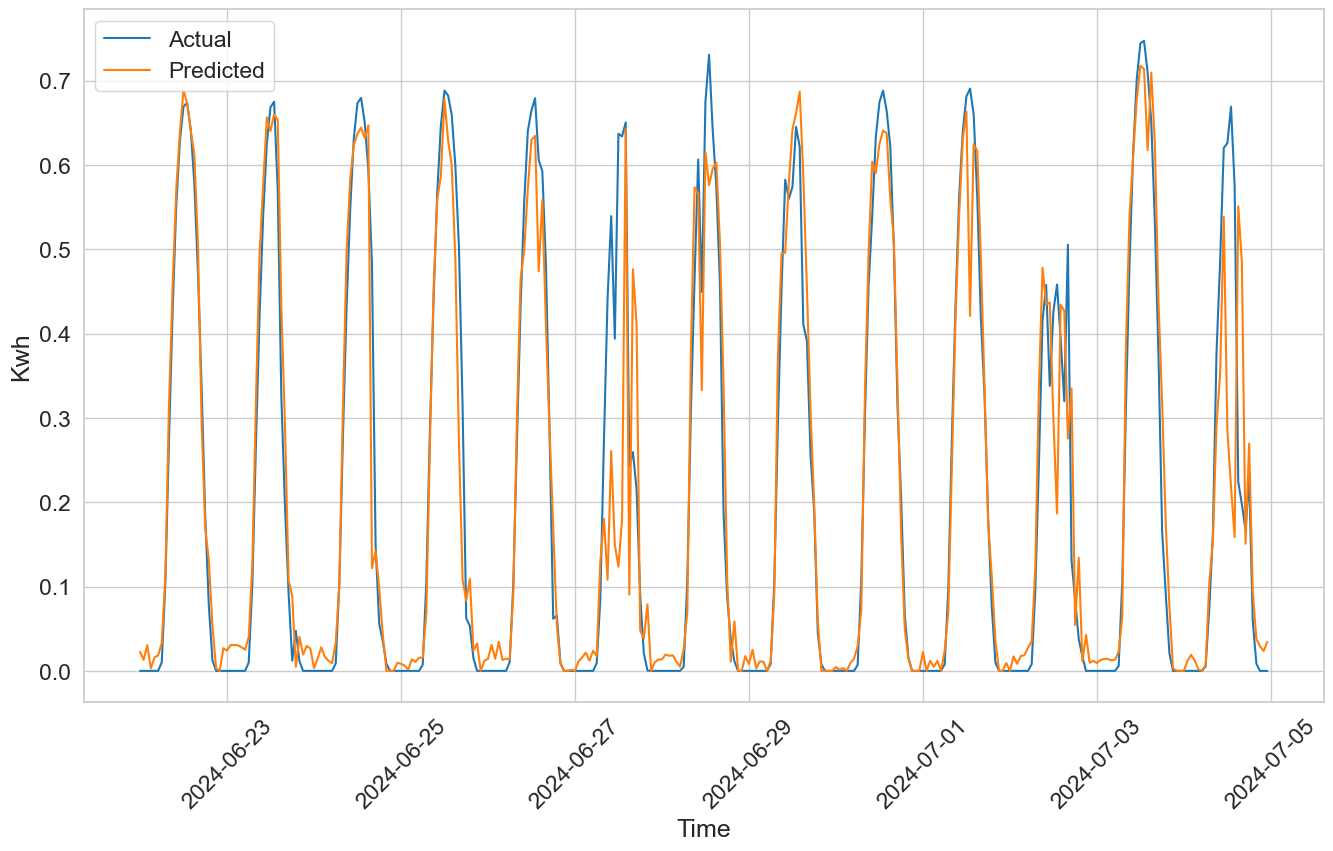

In [17]:
plt.figure(figsize= (16, 9))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.5)
sns.lineplot(x = date_range[-312: ], y = y_test[-312:], label='Actual')
sns.lineplot(x = date_range[-312: ], y = y_pred[-312:], label='Predicted')
#plt.title('Kwh Time Series Prediction')
plt.xlabel('Time')
plt.ylabel('Kwh')
plt.xticks(rotation=45)
plt.legend()
plt.show()


In [62]:
y_pred

array([0.0095024 , 0.02454194, 0.        , ..., 0.02919021, 0.02349001,
       0.03442173])

# Temperature

In [17]:
data_picked = data[['temp', 'dew', 'humidity', 'precip', 'windgust', 'windspeed', 'winddir', 'cloudcover', 'solarradiation']]

In [18]:
x = data_picked.iloc[:, 1:].values
y = data_picked.iloc[:, 0].values

x, y

(array([[2.000e+00, 7.551e+01, 0.000e+00, ..., 2.400e+02, 0.000e+00,
         0.000e+00],
        [2.000e+00, 7.551e+01, 0.000e+00, ..., 2.981e+02, 0.000e+00,
         0.000e+00],
        [2.000e+00, 8.161e+01, 0.000e+00, ..., 3.010e+02, 4.090e+01,
         0.000e+00],
        ...,
        [1.000e+01, 4.939e+01, 1.000e-01, ..., 0.000e+00, 6.370e+01,
         9.000e+00],
        [1.100e+01, 5.615e+01, 0.000e+00, ..., 0.000e+00, 6.550e+01,
         0.000e+00],
        [1.100e+01, 6.361e+01, 0.000e+00, ..., 0.000e+00, 6.830e+01,
         0.000e+00]]),
 array([ 6. ,  6. ,  4.9, ..., 21. , 20. , 18. ]))

In [19]:
x_train, x_test = x[: int(0.8 * len(x))] , x[int(0.8 * len(x)):]
y_train, y_test = y[: int(0.8 * len(y))], y[int(0.8 * len(y)):] 

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((17586, 8), (4397, 8), (17586,), (4397,))

In [20]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_x.fit_transform(x_train)
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

x_test = scaler_x.transform(x_test)
y_test = scaler_y.transform(y_test.reshape(-1, 1)).ravel()


In [21]:
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

svr_model.fit(x_train, y_train)


SVR()

In [22]:
y_pred = svr_model.predict(x_test)
y_pred

array([-0.53313166, -0.68340122, -0.79827148, ...,  0.91127097,
        0.79730708,  0.5320402 ])

In [23]:
y_pred = svr_model.predict(x_test)

y_pred = y_pred.reshape(-1, 1)
y_pred = scaler_y.inverse_transform(y_pred)

y_test = y_test.reshape(-1, 1)
y_test = scaler_y.inverse_transform(y_test)

y_pred = y_pred.ravel()
y_test = y_test.ravel()


In [24]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

Mean Squared Error: 0.43556202015443773
R² Score: 0.9941317530902575


In [25]:
date_range = pd.date_range(start='2024/1/3 19:00:00', end='2024/7/4 23:00:00', freq='H')
len(date_range)

4397

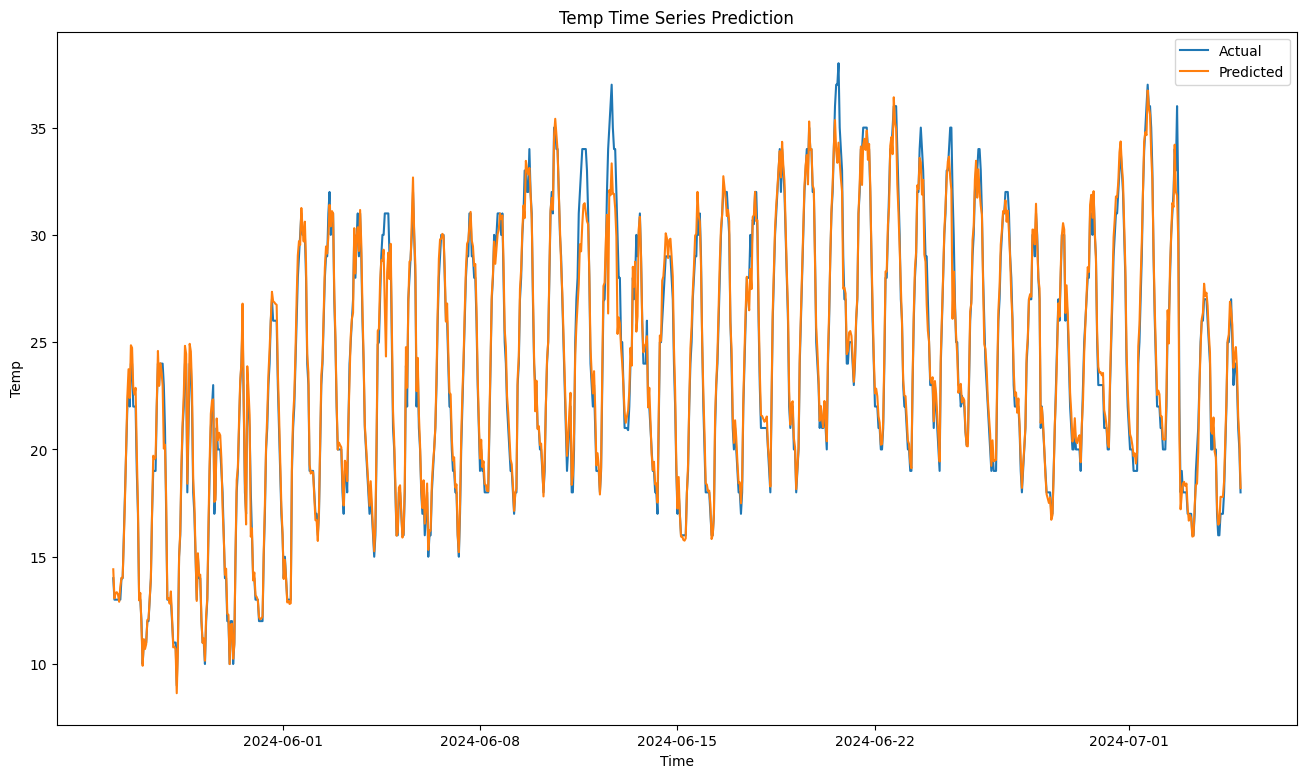

In [26]:
plt.figure(figsize= (16, 9))
sns.lineplot(x = date_range[-960: ], y = y_test[-960:], label='Actual')
sns.lineplot(x = date_range[-960: ], y = y_pred[-960:], label='Predicted')
plt.title('Temp Time Series Prediction')
plt.xlabel('Time')
plt.ylabel('Temp')
plt.legend()
plt.show()


In [27]:
date_range = pd.date_range(start='2024/1/3 19:00:00', end='2024/7/4 23:00:00', freq='H')
len(date_range)

4397